# GoEmotions null controls using Experiment 1 hyperparameters

This notebook recomputes the null-control experiment using the same label-centroid distance settings used in Experiment 1:

- full label-level VAD ground truth;
- PCA dimension 25;
- direct angular centroid distance;
- connected KNN geodesic distance with angular edge weights;
- automatic KNN choice: the smallest `k` that makes the symmetric graph connected.

It reports the observed Experiment 1 statistics and then evaluates the same statistics under the four null models.

In [1]:
# =========================
# Configuration
# =========================

from pathlib import Path

# Change these if your folder layout differs.
DATA_DIR = Path(r"D:/pyprojects/m4r/data/goemotions")
EMBEDDINGS_PATH = DATA_DIR / "manifold_outputs" / "embeddings.npy"
METADATA_PATH = DATA_DIR / "manifold_outputs" / "metadata.csv"
VAD_CSV_PATH = DATA_DIR / "emotion_label_vad_starter.csv"

# Plot/table outputs go here.
OUT_DIR = Path(r"D:/pyprojects/m4r/new_plots/null_controls_exp1_hyperparams")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Experiment 1 hyperparameters.
GROUND_TRUTH_SPACE = "VAD"
PCA_DIM_FOR_ANALYSIS = 25
KNN_K = "auto"                     # smallest connected k, as in Experiment 1
KNN_GRAPH_METRIC = "angular"       # angular edge weights, as in Experiment 1

# Use both embedding-side distances reported in Experiment 1.
DISTANCE_CONFIGS = [
    {
        "metric_name": "direct_angular",
        "method": "direct",
        "direct_metric": "angular",
    },
    {
        "metric_name": "knn_geodesic_angular",
        "method": "knn_geodesic",
        "knn_k": KNN_K,
        "graph_metric": KNN_GRAPH_METRIC,
    },
]

# PCA fitting mode.
# - "fit_on_centroids": fit PCA on the 28 raw label centroids, then transform comments.
#   This usually matches wording where the 28 x 3072 centroid matrix is projected to 25 PCs.
# - "fit_on_comments": fit PCA on all comment embeddings before averaging by label.
# - "auto_match_table": try both modes and choose the one whose observed Spearman values
#   best match EXPECTED_EXPERIMENT1_SPEARMAN below.
PCA_FIT_MODE = "auto_match_table"
EXPECTED_EXPERIMENT1_SPEARMAN = {
    "direct_angular": 0.633,
    "knn_geodesic_angular": 0.674,
}

# Null iterations. Use 500 to match the current write-up; increase for a tighter estimate.
N_NULL = 500
SEED = 42

# For random comment-centroid null.
# False means each pseudo-centroid samples comments without replacement internally.
# Different pseudo-centroids may still reuse the same comments.
RANDOM_CENTROIDS_REPLACE = False

# For Gaussian null.
# True matches each analysis-space centroid dimension's empirical mean/std.
# False uses standard normal vectors.
GAUSSIAN_MATCH_CENTROID_MEAN_STD = True

print("Output folder:", OUT_DIR)

Output folder: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams


In [2]:
# =========================
# Imports and helper functions
# =========================

import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import spearmanr, pearsonr, kendalltau

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors


VAD_SPACES = {
    "VAD": ["valence", "arousal", "dominance"],
    "VA": ["valence", "arousal"],
    "valence": ["valence"],
    "arousal": ["arousal"],
    "dominance": ["dominance"],
}


def upper_values(D):
    idx = np.triu_indices(D.shape[0], k=1)
    return D[idx]


def corr_row(truth_D, rep_D):
    truth = upper_values(truth_D)
    rep = upper_values(rep_D)
    mask = np.isfinite(truth) & np.isfinite(rep)
    truth = truth[mask]
    rep = rep[mask]

    if len(truth) < 3 or np.std(truth) == 0 or np.std(rep) == 0:
        return {
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "kendall_tau": np.nan,
            "kendall_p": np.nan,
            "n_pairs": int(len(truth)),
        }

    sr = spearmanr(truth, rep)
    pr = pearsonr(truth, rep)
    kt = kendalltau(truth, rep)
    return {
        "spearman_rho": float(sr.statistic),
        "spearman_p": float(sr.pvalue),
        "pearson_r": float(pr.statistic),
        "pearson_p": float(pr.pvalue),
        "kendall_tau": float(kt.statistic),
        "kendall_p": float(kt.pvalue),
        "n_pairs": int(len(truth)),
    }


def angular_pairwise(X):
    Xn = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
    sims = np.clip(Xn @ Xn.T, -1.0, 1.0)
    return np.arccos(sims)


def pairwise_rep_distance(X, method):
    if method == "angular":
        return angular_pairwise(X)
    if method == "cosine":
        return pairwise_distances(X, metric="cosine")
    if method == "euclidean":
        return pairwise_distances(X, metric="euclidean")
    raise ValueError(f"Unknown direct distance method: {method}")


def build_symmetric_knn_graph(X, k, metric):
    n = X.shape[0]
    if k >= n:
        raise ValueError(f"k must be smaller than n. Got k={k}, n={n}")

    if metric == "angular":
        Xn = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
        nbrs.fit(Xn)
        _, indices = nbrs.kneighbors(Xn)
        indices = indices[:, 1:]

        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        sims = np.sum(Xn[rows] * Xn[cols], axis=1)
        vals = np.arccos(np.clip(sims, -1.0, 1.0))
    else:
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric=metric)
        nbrs.fit(X)
        distances, indices = nbrs.kneighbors(X)
        distances = distances[:, 1:]
        indices = indices[:, 1:]

        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        vals = distances.ravel()

    G = csr_matrix((vals, (rows, cols)), shape=(n, n))
    return G.maximum(G.T)


def connected_k(X, metric, k_max=None):
    n = X.shape[0]
    if k_max is None:
        k_max = n - 1
    upper = min(k_max, n - 1)

    for k in range(1, upper + 1):
        G = build_symmetric_knn_graph(X, k=k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
        if n_components == 1:
            return k, G

    raise ValueError(f"Graph did not become connected up to k={upper}")


def geodesic_distance(X, k_value="auto", metric="angular"):
    if k_value == "auto":
        actual_k, G = connected_k(X, metric=metric)
        n_components = 1
    else:
        actual_k = int(k_value)
        G = build_symmetric_knn_graph(X, k=actual_k, metric=metric)
        n_components, _ = connected_components(G, directed=False)

    D = dijkstra(csgraph=G, directed=False, return_predecessors=False)
    return D, actual_k, int(n_components)


def vad_distance_from_array(vad_array, space):
    cols = VAD_SPACES[space]
    col_idx = [{"valence": 0, "arousal": 1, "dominance": 2}[c] for c in cols]
    return pairwise_distances(vad_array[:, col_idx], metric="euclidean")


def empirical_p_values(null_values, observed):
    null_values = np.asarray(null_values, dtype=float)
    null_values = null_values[np.isfinite(null_values)]
    if len(null_values) == 0 or not np.isfinite(observed):
        return np.nan, np.nan, np.nan

    # One-sided test for the intended effect: larger positive correlation.
    p_greater = (np.sum(null_values >= observed) + 1) / (len(null_values) + 1)

    # Absolute-value version in case the write-up wants a magnitude-only comparison.
    p_abs = (np.sum(np.abs(null_values) >= abs(observed)) + 1) / (len(null_values) + 1)

    percentile = 100.0 * np.mean(null_values <= observed)
    return float(p_greater), float(p_abs), float(percentile)


def check_config():
    if GROUND_TRUTH_SPACE not in VAD_SPACES:
        raise ValueError(f"Unknown GROUND_TRUTH_SPACE: {GROUND_TRUTH_SPACE}")
    if PCA_FIT_MODE not in {"fit_on_centroids", "fit_on_comments", "auto_match_table"}:
        raise ValueError("PCA_FIT_MODE must be 'fit_on_centroids', 'fit_on_comments', or 'auto_match_table'")
    if KNN_GRAPH_METRIC not in {"angular", "cosine", "euclidean"}:
        raise ValueError("KNN_GRAPH_METRIC must be 'angular', 'cosine', or 'euclidean'")
    if N_NULL < 10:
        warnings.warn("N_NULL is very small. Use this only for smoke testing.")
    names = [cfg["metric_name"] for cfg in DISTANCE_CONFIGS]
    if len(names) != len(set(names)):
        raise ValueError("DISTANCE_CONFIGS contains duplicate metric_name values")


check_config()

In [3]:
# =========================
# Load data
# =========================

X_raw = np.load(EMBEDDINGS_PATH)
metadata = pd.read_csv(METADATA_PATH).reset_index(drop=True)
vad_df = pd.read_csv(VAD_CSV_PATH)

required_meta = {"label_name", "label_idx"}
missing_meta = required_meta - set(metadata.columns)
if missing_meta:
    raise ValueError(f"metadata.csv is missing columns: {sorted(missing_meta)}")

required_vad = {"label_name", "valence", "arousal", "dominance"}
missing_vad = required_vad - set(vad_df.columns)
if missing_vad:
    raise ValueError(f"VAD CSV is missing columns: {sorted(missing_vad)}")

for col in ["valence", "arousal", "dominance"]:
    vad_df[col] = pd.to_numeric(vad_df[col], errors="coerce")
if vad_df[["valence", "arousal", "dominance"]].isna().any().any():
    bad = vad_df[vad_df[["valence", "arousal", "dominance"]].isna().any(axis=1)]
    raise ValueError("Some VAD rows contain missing/non-numeric values:\n" + bad.to_string(index=False))

if len(X_raw) != len(metadata):
    raise ValueError(f"Embeddings and metadata lengths differ: {len(X_raw)} vs {len(metadata)}")

print("Embeddings:", X_raw.shape)
print("Metadata:", metadata.shape)
print("Labels:", metadata["label_name"].nunique())
metadata["label_name"].value_counts().sort_index().head()

Embeddings: (4997, 3072)
Metadata: (4997, 5)
Labels: 28


label_name
admiration    201
amusement     201
anger         201
annoyance     201
approval      201
Name: count, dtype: int64

In [4]:
# =========================
# Label table and centroid helpers
# =========================

def make_label_table(metadata, vad_df):
    rows = []
    for label_name, group in metadata.groupby("label_name", sort=True):
        rows.append({
            "label_name": label_name,
            "label_idx": int(group["label_idx"].iloc[0]),
            "n_comments": int(len(group)),
        })
    label_df = pd.DataFrame(rows)
    label_df = label_df.merge(
        vad_df[["label_name", "valence", "arousal", "dominance"]],
        on="label_name",
        how="left",
    )
    if label_df[["valence", "arousal", "dominance"]].isna().any().any():
        missing = label_df.loc[label_df["valence"].isna(), "label_name"].tolist()
        raise ValueError(f"Missing VAD coordinates for labels: {missing}")
    return label_df


def centroids_from_codes(X, codes, n_labels):
    sums = np.zeros((n_labels, X.shape[1]), dtype=np.float64)
    counts = np.bincount(codes, minlength=n_labels).astype(float)
    np.add.at(sums, codes, X)
    if np.any(counts == 0):
        empty = np.where(counts == 0)[0].tolist()
        raise ValueError(f"At least one label has no assigned comments: {empty}")
    return sums / counts[:, None]


label_df = make_label_table(metadata, vad_df)
label_order = label_df["label_name"].tolist()
label_to_code = {label: i for i, label in enumerate(label_order)}
n_labels = len(label_order)

group_sizes = label_df["n_comments"].to_numpy(dtype=int)
real_vad = label_df[["valence", "arousal", "dominance"]].to_numpy(dtype=float)
real_truth_D = vad_distance_from_array(real_vad, GROUND_TRUTH_SPACE)

original_codes = metadata["label_name"].map(label_to_code).to_numpy(dtype=int)
if np.any(pd.isna(original_codes)):
    raise ValueError("Some metadata labels are missing from label_order")

raw_real_centroids = centroids_from_codes(X_raw, original_codes, n_labels)

print("Raw real centroid matrix:", raw_real_centroids.shape)
label_df

Raw real centroid matrix: (28, 3072)


,label_name,label_idx,n_comments,valence,arousal,dominance
0,admiration,0,201,7.74,6.11,7.53
1,amusement,1,201,7.00,6.00,6.00
2,anger,2,201,2.85,7.17,5.55
3,annoyance,3,201,2.74,6.49,5.09
4,approval,4,201,7.33,5.83,6.89
5,caring,5,201,6.50,4.50,5.50
6,confusion,6,201,3.21,6.03,4.24
7,curiosity,7,201,6.08,5.82,5.42
8,desire,8,201,7.69,7.35,6.49
9,disappointment,9,201,2.39,4.92,3.29


In [5]:
# =========================
# Analysis-space construction and metric scoring
# =========================

def make_analysis_space(mode):
    # Return transformed comment embeddings and PCA metadata for one PCA fitting mode.
    if PCA_DIM_FOR_ANALYSIS and PCA_DIM_FOR_ANALYSIS > 0:
        if mode == "fit_on_centroids":
            fit_matrix = raw_real_centroids
        elif mode == "fit_on_comments":
            fit_matrix = X_raw
        else:
            raise ValueError(f"Unknown analysis-space mode: {mode}")

        n_components = min(PCA_DIM_FOR_ANALYSIS, fit_matrix.shape[0] - 1, fit_matrix.shape[1])
        pca = PCA(n_components=n_components, random_state=SEED)
        pca.fit(fit_matrix)
        X_analysis = pca.transform(X_raw)
        explained_variance = float(pca.explained_variance_ratio_.sum())
        representation_name = f"pca_{n_components}_{mode}"
    else:
        X_analysis = X_raw.copy()
        pca = None
        explained_variance = math.nan
        representation_name = "raw"

    C_real = centroids_from_codes(X_analysis, original_codes, n_labels)
    return {
        "mode": mode,
        "X_analysis": X_analysis,
        "real_centroids": C_real,
        "pca": pca,
        "representation_name": representation_name,
        "explained_variance": explained_variance,
        "embedding_dim_used": int(X_analysis.shape[1]),
    }


def representation_distance_for_config(centroids, cfg):
    if cfg["method"] == "direct":
        rep_D = pairwise_rep_distance(centroids, cfg["direct_metric"])
        return rep_D, None, None
    if cfg["method"] == "knn_geodesic":
        return geodesic_distance(
            centroids,
            k_value=cfg.get("knn_k", "auto"),
            metric=cfg.get("graph_metric", "angular"),
        )
    raise ValueError(f"Unknown distance method: {cfg['method']}")


def score_centroids(centroids, truth_D, cfg):
    rep_D, actual_k, components = representation_distance_for_config(centroids, cfg)
    stats = corr_row(truth_D, rep_D)
    return stats, rep_D, actual_k, components


def observed_for_space(space):
    rows = []
    rep_matrices = {}
    for cfg in DISTANCE_CONFIGS:
        stats, rep_D, actual_k, components = score_centroids(space["real_centroids"], real_truth_D, cfg)
        rep_matrices[cfg["metric_name"]] = rep_D
        rows.append({
            "metric_name": cfg["metric_name"],
            "method": cfg["method"],
            "direct_metric": cfg.get("direct_metric", ""),
            "graph_metric": cfg.get("graph_metric", ""),
            "knn_k": actual_k if actual_k is not None else "",
            "graph_connected_components": components if components is not None else "",
            "ground_truth_space": GROUND_TRUTH_SPACE,
            "pca_fit_mode": space["mode"],
            "representation": space["representation_name"],
            "explained_variance": space["explained_variance"],
            "embedding_dim_used": space["embedding_dim_used"],
            **stats,
        })
    return pd.DataFrame(rows), rep_matrices

In [6]:
# =========================
# Choose PCA mode and compute the observed Experiment 1 statistics
# =========================

if PCA_FIT_MODE == "auto_match_table":
    candidate_rows = []
    candidate_spaces = {}
    candidate_rep_matrices = {}

    for mode in ["fit_on_centroids", "fit_on_comments"]:
        space = make_analysis_space(mode)
        obs_df_mode, rep_matrices = observed_for_space(space)
        candidate_spaces[mode] = space
        candidate_rep_matrices[mode] = rep_matrices

        error = 0.0
        for metric_name, expected in EXPECTED_EXPERIMENT1_SPEARMAN.items():
            match = obs_df_mode.loc[obs_df_mode["metric_name"].eq(metric_name), "spearman_rho"]
            if len(match):
                error += float((match.iloc[0] - expected) ** 2)
            else:
                error += 1e9

        tmp = obs_df_mode.copy()
        tmp["match_error_to_expected_table"] = error
        candidate_rows.append(tmp)

    candidate_df = pd.concat(candidate_rows, ignore_index=True)
    chosen_mode = (
        candidate_df[["pca_fit_mode", "match_error_to_expected_table"]]
        .drop_duplicates()
        .sort_values("match_error_to_expected_table")
        .iloc[0]["pca_fit_mode"]
    )
    analysis_space = candidate_spaces[chosen_mode]
    observed_df, observed_rep_matrices = observed_for_space(analysis_space)

    print("PCA mode candidates compared against EXPECTED_EXPERIMENT1_SPEARMAN:")
    display(candidate_df[[
        "pca_fit_mode", "metric_name", "spearman_rho", "pearson_r",
        "knn_k", "graph_connected_components", "match_error_to_expected_table",
    ]])
    print("Chosen PCA_FIT_MODE:", chosen_mode)
else:
    analysis_space = make_analysis_space(PCA_FIT_MODE)
    observed_df, observed_rep_matrices = observed_for_space(analysis_space)
    chosen_mode = PCA_FIT_MODE

X_analysis = analysis_space["X_analysis"]
real_centroids = analysis_space["real_centroids"]

observed_path = OUT_DIR / "observed_alignment_exp1_hyperparams.csv"
observed_df.to_csv(observed_path, index=False)

print("Observed Experiment 1-style alignment")
print("-------------------------------------")
print("Saved:", observed_path)
observed_df

PCA mode candidates compared against EXPECTED_EXPERIMENT1_SPEARMAN:


,pca_fit_mode,metric_name,spearman_rho,pearson_r,knn_k,graph_connected_components,match_error_to_expected_table
0,fit_on_centroids,direct_angular,0.633224,0.604641,,,5.880746e-08
1,fit_on_centroids,knn_geodesic_angular,0.674093,0.694175,2,1,5.880746e-08
2,fit_on_comments,direct_angular,0.613444,0.599500,,,4.286456e-02
3,fit_on_comments,knn_geodesic_angular,0.467888,0.445617,2,1,4.286456e-02


Chosen PCA_FIT_MODE: fit_on_centroids
Observed Experiment 1-style alignment
-------------------------------------
Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\observed_alignment_exp1_hyperparams.csv


,metric_name,method,direct_metric,graph_metric,knn_k,graph_connected_components,ground_truth_space,pca_fit_mode,representation,explained_variance,embedding_dim_used,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p,n_pairs
0,direct_angular,direct,angular,,,,VAD,fit_on_centroids,pca_25_fit_on_centroids,0.992096,25,0.633224,9.348724e-44,0.604641,4.743191e-39,0.442871,7.990012e-38,378
1,knn_geodesic_angular,knn_geodesic,,angular,2,1,VAD,fit_on_centroids,pca_25_fit_on_centroids,0.992096,25,0.674093,2.071191e-51,0.694175,1.214886e-55,0.475011,2.982520e-43,378


In [7]:
# =========================
# Null model generators
# =========================

rng = np.random.default_rng(SEED)


def null_shuffle_emotion_labels(X_analysis, rng):
    # Preserves original label counts but destroys which comments belong to each label.
    shuffled_codes = original_codes.copy()
    rng.shuffle(shuffled_codes)
    return centroids_from_codes(X_analysis, shuffled_codes, n_labels)


def null_shuffle_vad_coordinates(real_vad, rng):
    # Preserves the VAD coordinate cloud but breaks label-to-coordinate identity.
    return real_vad[rng.permutation(len(real_vad))]


def null_gaussian_centroids(real_centroids, rng):
    # Replaces the 28 analysis-space centroids with random vectors of the same shape.
    if GAUSSIAN_MATCH_CENTROID_MEAN_STD:
        mu = real_centroids.mean(axis=0, keepdims=True)
        sd = real_centroids.std(axis=0, ddof=1, keepdims=True)
        sd = np.maximum(sd, 1e-12)
        return rng.normal(loc=mu, scale=sd, size=real_centroids.shape)
    return rng.normal(size=real_centroids.shape)


def null_random_comment_centroids(X_analysis, group_sizes, rng):
    # For each label, sample the same number of comments as that real label, ignoring labels.
    rows = []
    for size in group_sizes:
        replace = RANDOM_CENTROIDS_REPLACE or size > len(X_analysis)
        idx = rng.choice(len(X_analysis), size=int(size), replace=replace)
        rows.append(X_analysis[idx].mean(axis=0))
    return np.vstack(rows)


def add_null_scores(null_rows, iteration, null_model, centroids=None, vad_array=None):
    for cfg in DISTANCE_CONFIGS:
        metric_name = cfg["metric_name"]

        if vad_array is None:
            truth_D = real_truth_D
        else:
            truth_D = vad_distance_from_array(vad_array, GROUND_TRUTH_SPACE)

        if centroids is None:
            # Used for VAD-shuffle null: embedding distances stay exactly equal to the observed metric.
            rep_D = observed_rep_matrices[metric_name]
            actual_k = observed_df.loc[observed_df["metric_name"].eq(metric_name), "knn_k"].iloc[0]
            components = observed_df.loc[observed_df["metric_name"].eq(metric_name), "graph_connected_components"].iloc[0]
            stats = corr_row(truth_D, rep_D)
        else:
            stats, _, actual_k, components = score_centroids(centroids, truth_D, cfg)

        null_rows.append({
            "iteration": iteration,
            "null_model": null_model,
            "metric_name": metric_name,
            "method": cfg["method"],
            "direct_metric": cfg.get("direct_metric", ""),
            "graph_metric": cfg.get("graph_metric", ""),
            "knn_k": actual_k if actual_k is not None else "",
            "graph_connected_components": components if components is not None else "",
            "ground_truth_space": GROUND_TRUTH_SPACE,
            "pca_fit_mode": chosen_mode,
            "representation": analysis_space["representation_name"],
            "embedding_dim_used": analysis_space["embedding_dim_used"],
            **stats,
        })

In [8]:
# =========================
# Run null controls
# =========================

null_rows = []

for i in range(N_NULL):
    # 1. Shuffle labels across comments.
    C_label_shuffle = null_shuffle_emotion_labels(X_analysis, rng)
    add_null_scores(
        null_rows,
        iteration=i,
        null_model="shuffle_emotion_labels_across_comments",
        centroids=C_label_shuffle,
    )

    # 2. Shuffle VAD coordinates across labels.
    vad_shuffle = null_shuffle_vad_coordinates(real_vad, rng)
    add_null_scores(
        null_rows,
        iteration=i,
        null_model="shuffle_vad_coordinates_across_labels",
        vad_array=vad_shuffle,
    )

    # 3. Gaussian random vectors in the same analysis feature space.
    C_gaussian = null_gaussian_centroids(real_centroids, rng)
    add_null_scores(
        null_rows,
        iteration=i,
        null_model="random_gaussian_vectors_same_analysis_dimensionality",
        centroids=C_gaussian,
    )

    # 4. Random centroids sampled from comments regardless of label.
    C_random_comment = null_random_comment_centroids(X_analysis, group_sizes, rng)
    add_null_scores(
        null_rows,
        iteration=i,
        null_model="random_centroids_from_comments_ignore_label",
        centroids=C_random_comment,
    )

    if (i + 1) % max(1, N_NULL // 10) == 0:
        print(f"Completed {i + 1}/{N_NULL} null iterations")

null_df = pd.DataFrame(null_rows)
null_scores_path = OUT_DIR / "null_control_scores_exp1_hyperparams.csv"
null_df.to_csv(null_scores_path, index=False)

print("Saved:", null_scores_path)
null_df.head()

Completed 50/500 null iterations
Completed 100/500 null iterations
Completed 150/500 null iterations
Completed 200/500 null iterations
Completed 250/500 null iterations
Completed 300/500 null iterations
Completed 350/500 null iterations
Completed 400/500 null iterations
Completed 450/500 null iterations
Completed 500/500 null iterations
Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\null_control_scores_exp1_hyperparams.csv


,iteration,null_model,metric_name,method,direct_metric,graph_metric,knn_k,graph_connected_components,ground_truth_space,pca_fit_mode,representation,embedding_dim_used,spearman_rho,spearman_p,pearson_r,pearson_p,kendall_tau,kendall_p,n_pairs
0,0,shuffle_emotion_labels_across_comments,direct_angular,direct,angular,,,,VAD,fit_on_centroids,pca_25_fit_on_centroids,25,0.018894,0.714254,-0.010754,0.834915,0.011663,0.734945,378
1,0,shuffle_emotion_labels_across_comments,knn_geodesic_angular,knn_geodesic,,angular,2,1,VAD,fit_on_centroids,pca_25_fit_on_centroids,25,0.025303,0.623848,0.018293,0.722958,0.016491,0.632151,378
2,0,shuffle_vad_coordinates_across_labels,direct_angular,direct,angular,,,,VAD,fit_on_centroids,pca_25_fit_on_centroids,25,-0.002366,0.963436,-0.021880,0.671540,-0.000856,0.980173,378
3,0,shuffle_vad_coordinates_across_labels,knn_geodesic_angular,knn_geodesic,,angular,2,1,VAD,fit_on_centroids,pca_25_fit_on_centroids,25,-0.068959,0.180939,-0.088079,0.087246,-0.044477,0.196679,378
4,0,random_gaussian_vectors_same_analysis_dimensio...,direct_angular,direct,angular,,,,VAD,fit_on_centroids,pca_25_fit_on_centroids,25,-0.029179,0.571697,-0.018394,0.721498,-0.018793,0.585398,378


In [9]:
# =========================
# Summarise observed vs null distributions
# =========================

summary_rows = []

for (metric_name, null_name), group in null_df.groupby(["metric_name", "null_model"], sort=False):
    vals = group["spearman_rho"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    obs_row = observed_df.loc[observed_df["metric_name"].eq(metric_name)].iloc[0]
    observed_rho = float(obs_row["spearman_rho"])
    p_greater, p_abs, percentile = empirical_p_values(vals, observed_rho)

    summary_rows.append({
        "metric_name": metric_name,
        "null_model": null_name,
        "observed_spearman_rho": observed_rho,
        "observed_pearson_r": float(obs_row["pearson_r"]),
        "observed_k": obs_row["knn_k"],
        "observed_components": obs_row["graph_connected_components"],
        "null_mean": np.mean(vals),
        "null_std": np.std(vals, ddof=1),
        "null_q025": np.quantile(vals, 0.025),
        "null_median": np.quantile(vals, 0.5),
        "null_q975": np.quantile(vals, 0.975),
        "observed_percentile_vs_null": percentile,
        "empirical_p_greater_equal_observed": p_greater,
        "empirical_p_abs_greater_equal_abs_observed": p_abs,
        "n_null": len(vals),
        "ground_truth_space": GROUND_TRUTH_SPACE,
        "pca_dim_for_analysis": PCA_DIM_FOR_ANALYSIS,
        "pca_fit_mode": chosen_mode,
        "representation": analysis_space["representation_name"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = OUT_DIR / "null_control_summary_exp1_hyperparams.csv"
summary_df.to_csv(summary_path, index=False)

paper_summary = summary_df[[
    "metric_name",
    "null_model",
    "observed_spearman_rho",
    "null_mean",
    "null_std",
    "null_q975",
    "observed_percentile_vs_null",
    "empirical_p_greater_equal_observed",
    "n_null",
    "pca_fit_mode",
]]

print("Saved:", summary_path)
paper_summary

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\null_control_summary_exp1_hyperparams.csv


,metric_name,null_model,observed_spearman_rho,null_mean,null_std,null_q975,observed_percentile_vs_null,empirical_p_greater_equal_observed,n_null,pca_fit_mode
0,direct_angular,shuffle_emotion_labels_across_comments,0.633224,0.004954,0.051522,0.119954,100.0,0.001996,500,fit_on_centroids
1,knn_geodesic_angular,shuffle_emotion_labels_across_comments,0.674093,0.006799,0.050396,0.111259,100.0,0.001996,500,fit_on_centroids
2,direct_angular,shuffle_vad_coordinates_across_labels,0.633224,0.001900,0.049463,0.113954,100.0,0.001996,500,fit_on_centroids
3,knn_geodesic_angular,shuffle_vad_coordinates_across_labels,0.674093,-0.000354,0.047100,0.114973,100.0,0.001996,500,fit_on_centroids
4,direct_angular,random_gaussian_vectors_same_analysis_dimensio...,0.633224,0.000321,0.047408,0.102431,100.0,0.001996,500,fit_on_centroids
5,knn_geodesic_angular,random_gaussian_vectors_same_analysis_dimensio...,0.674093,0.001416,0.052207,0.122990,100.0,0.001996,500,fit_on_centroids
6,direct_angular,random_centroids_from_comments_ignore_label,0.633224,0.009544,0.052809,0.126389,100.0,0.001996,500,fit_on_centroids
7,knn_geodesic_angular,random_centroids_from_comments_ignore_label,0.674093,0.005945,0.054761,0.139568,100.0,0.001996,500,fit_on_centroids


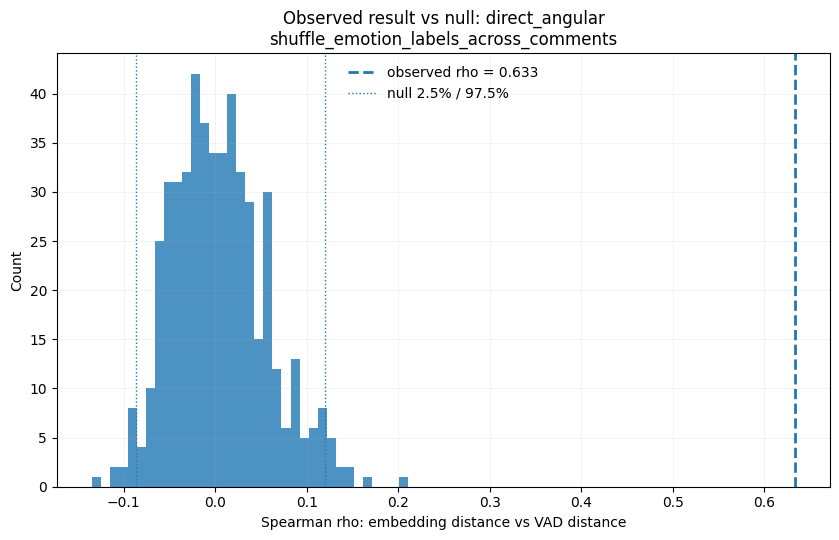

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\hist_direct_angular_shuffle_emotion_labels_across_comments_VAD.png


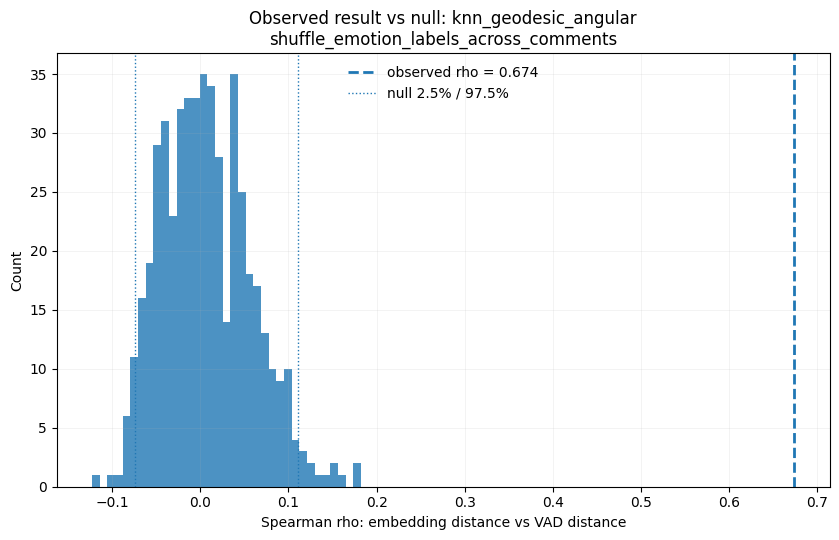

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\hist_knn_geodesic_angular_shuffle_emotion_labels_across_comments_VAD.png


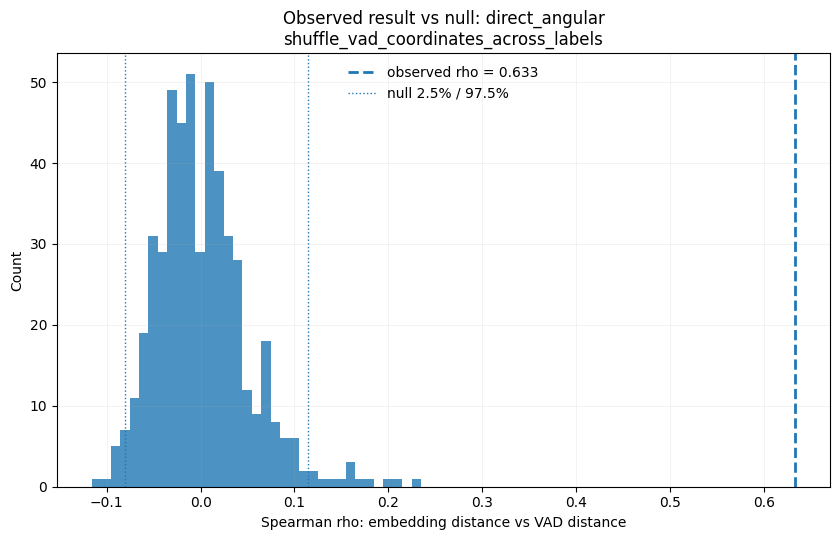

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\hist_direct_angular_shuffle_vad_coordinates_across_labels_VAD.png


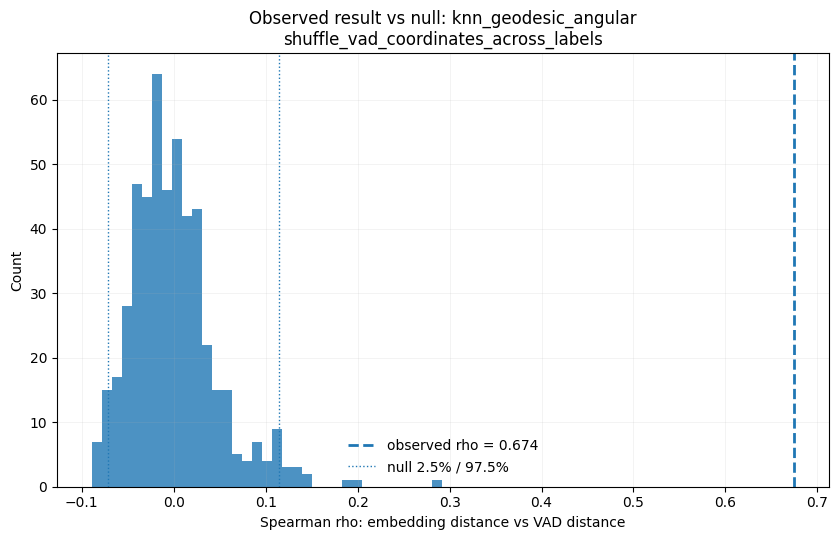

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\hist_knn_geodesic_angular_shuffle_vad_coordinates_across_labels_VAD.png


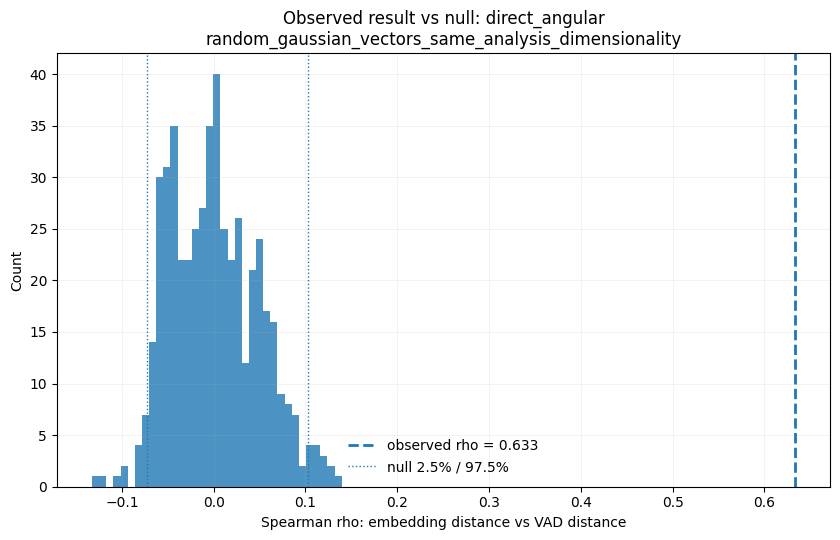

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\hist_direct_angular_random_gaussian_vectors_same_analysis_dimensionality_VAD.png


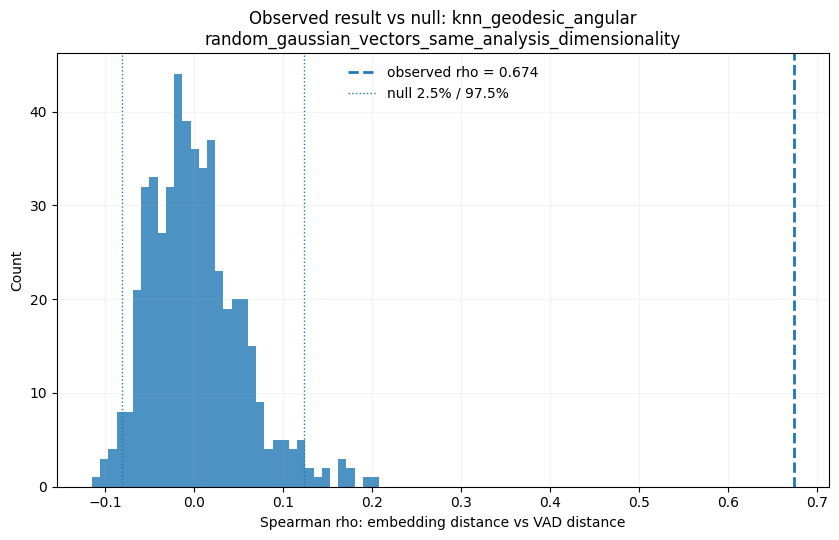

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\hist_knn_geodesic_angular_random_gaussian_vectors_same_analysis_dimensionality_VAD.png


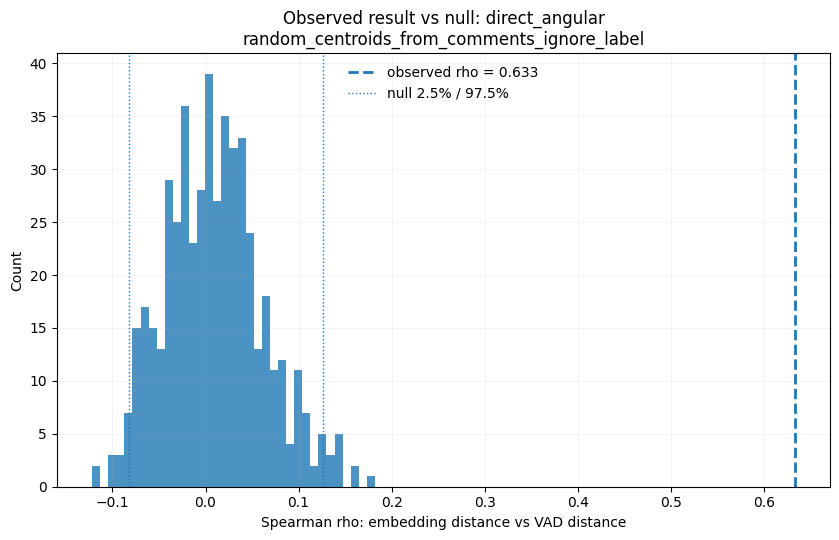

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\hist_direct_angular_random_centroids_from_comments_ignore_label_VAD.png


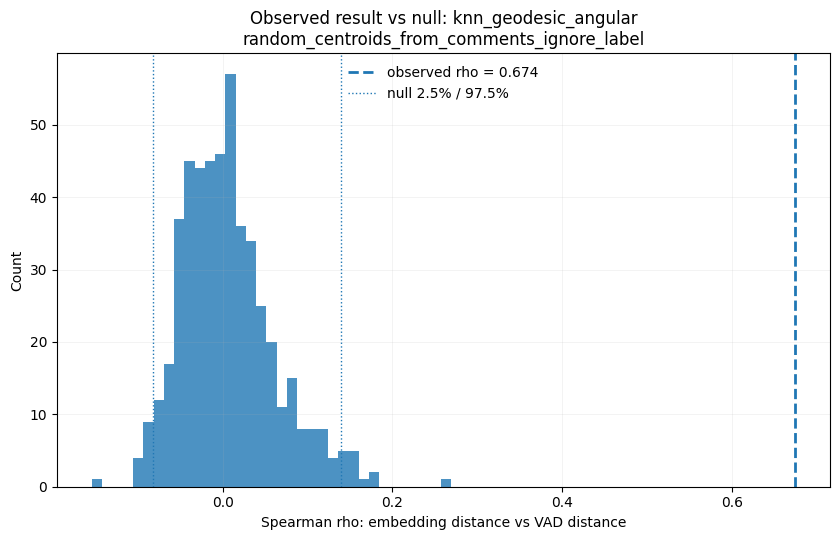

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\hist_knn_geodesic_angular_random_centroids_from_comments_ignore_label_VAD.png


In [10]:
# =========================
# Plot: one histogram per null model and metric
# =========================

safe_truth_name = GROUND_TRUTH_SPACE.replace("/", "_")

for (metric_name, null_name), group in null_df.groupby(["metric_name", "null_model"], sort=False):
    vals = group["spearman_rho"].dropna().to_numpy()
    obs = float(observed_df.loc[observed_df["metric_name"].eq(metric_name), "spearman_rho"].iloc[0])

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.hist(vals, bins=35, alpha=0.8)
    ax.axvline(obs, linestyle="--", linewidth=2, label=f"observed rho = {obs:.3f}")
    ax.axvline(np.quantile(vals, 0.025), linestyle=":", linewidth=1, label="null 2.5% / 97.5%")
    ax.axvline(np.quantile(vals, 0.975), linestyle=":", linewidth=1)

    ax.set_title(f"Observed result vs null: {metric_name}\n{null_name}")
    ax.set_xlabel("Spearman rho: embedding distance vs VAD distance")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)
    ax.grid(True, linewidth=0.4, alpha=0.25)
    fig.tight_layout()

    out_file = OUT_DIR / f"hist_{metric_name}_{null_name}_{safe_truth_name}.png"
    fig.savefig(out_file, dpi=220)
    plt.show()
    plt.close(fig)

    print("Saved:", out_file)

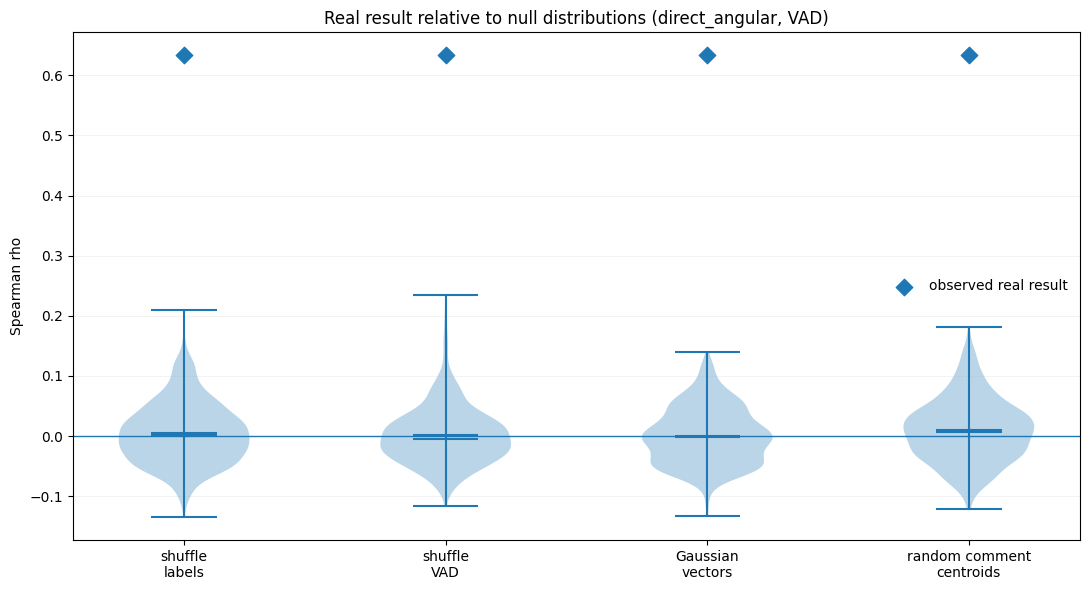

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\violin_null_controls_direct_angular_VAD.png


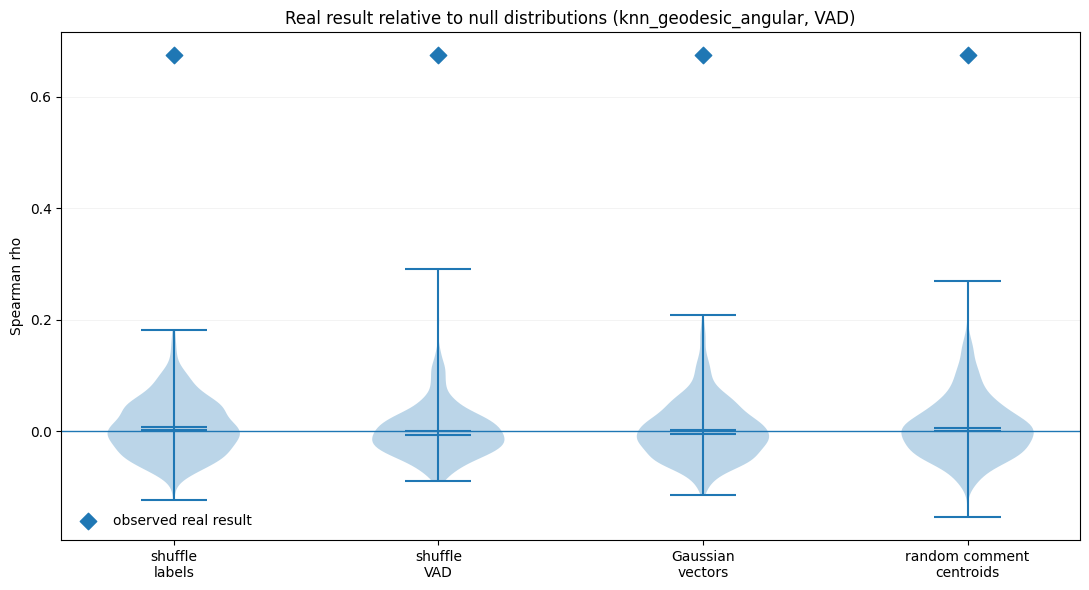

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\violin_null_controls_knn_geodesic_angular_VAD.png


In [11]:
# =========================
# Plot: combined violin plot, one panel per Experiment 1 distance metric
# =========================

short_names = {
    "shuffle_emotion_labels_across_comments": "shuffle\nlabels",
    "shuffle_vad_coordinates_across_labels": "shuffle\nVAD",
    "random_gaussian_vectors_same_analysis_dimensionality": "Gaussian\nvectors",
    "random_centroids_from_comments_ignore_label": "random comment\ncentroids",
}

for metric_name, metric_group in null_df.groupby("metric_name", sort=False):
    null_names = list(metric_group["null_model"].drop_duplicates())
    data = [
        metric_group.loc[metric_group["null_model"].eq(name), "spearman_rho"].dropna().to_numpy()
        for name in null_names
    ]
    obs = float(observed_df.loc[observed_df["metric_name"].eq(metric_name), "spearman_rho"].iloc[0])

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.violinplot(data, showmeans=True, showmedians=True)

    x_positions = np.arange(1, len(null_names) + 1)
    ax.scatter(x_positions, [obs] * len(null_names), marker="D", s=70, label="observed real result")

    ax.set_xticks(x_positions)
    ax.set_xticklabels([short_names.get(name, name) for name in null_names], rotation=0)
    ax.set_ylabel("Spearman rho")
    ax.set_title(f"Real result relative to null distributions ({metric_name}, {GROUND_TRUTH_SPACE})")
    ax.axhline(0, linewidth=1)
    ax.legend(frameon=False)
    ax.grid(True, axis="y", linewidth=0.4, alpha=0.25)
    fig.tight_layout()

    violin_path = OUT_DIR / f"violin_null_controls_{metric_name}_{safe_truth_name}.png"
    fig.savefig(violin_path, dpi=220)
    plt.show()
    plt.close(fig)

    print("Saved:", violin_path)

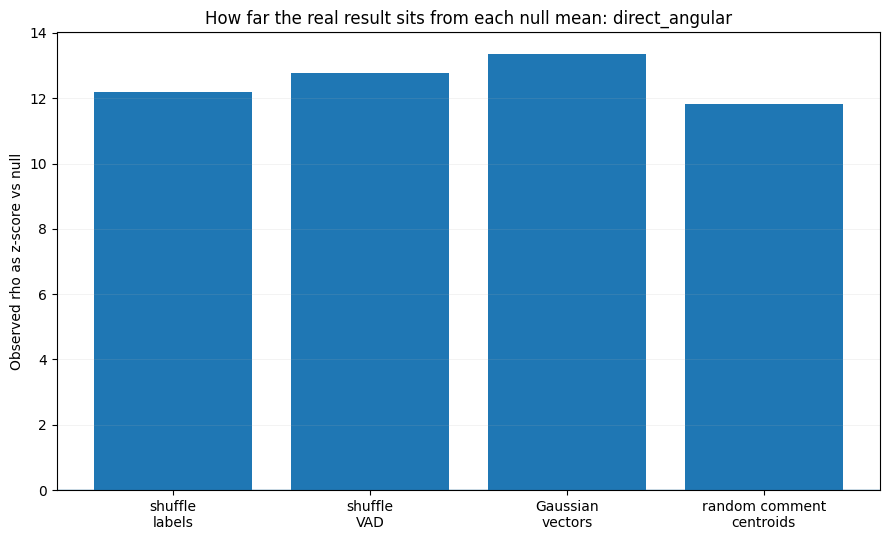

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\zscore_vs_null_controls_direct_angular_VAD.png


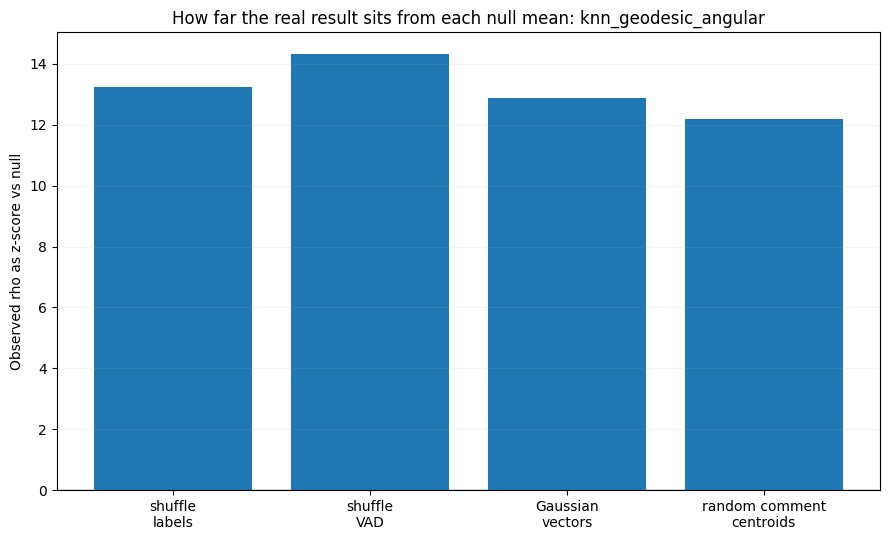

Saved: D:\pyprojects\m4r\new_plots\null_controls_exp1_hyperparams\zscore_vs_null_controls_knn_geodesic_angular_VAD.png


,metric_name,null_model,observed_spearman_rho,null_mean,null_std,z_vs_null,observed_percentile_vs_null,empirical_p_greater_equal_observed,empirical_p_abs_greater_equal_abs_observed
0,direct_angular,shuffle_emotion_labels_across_comments,0.633224,0.004954,0.051522,12.194255,100.0,0.001996,0.001996
1,knn_geodesic_angular,shuffle_emotion_labels_across_comments,0.674093,0.006799,0.050396,13.240937,100.0,0.001996,0.001996
2,direct_angular,shuffle_vad_coordinates_across_labels,0.633224,0.001900,0.049463,12.763483,100.0,0.001996,0.001996
3,knn_geodesic_angular,shuffle_vad_coordinates_across_labels,0.674093,-0.000354,0.047100,14.319482,100.0,0.001996,0.001996
4,direct_angular,random_gaussian_vectors_same_analysis_dimensio...,0.633224,0.000321,0.047408,13.350260,100.0,0.001996,0.001996
5,knn_geodesic_angular,random_gaussian_vectors_same_analysis_dimensio...,0.674093,0.001416,0.052207,12.884807,100.0,0.001996,0.001996
6,direct_angular,random_centroids_from_comments_ignore_label,0.633224,0.009544,0.052809,11.810066,100.0,0.001996,0.001996
7,knn_geodesic_angular,random_centroids_from_comments_ignore_label,0.674093,0.005945,0.054761,12.201118,100.0,0.001996,0.001996


In [12]:
# =========================
# Plot: z-score style summary
# =========================

plot_df = summary_df.copy()
plot_df["z_vs_null"] = (
    (plot_df["observed_spearman_rho"] - plot_df["null_mean"])
    / plot_df["null_std"].replace(0, np.nan)
)

for metric_name, metric_group in plot_df.groupby("metric_name", sort=False):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(len(metric_group))
    ax.bar(x, metric_group["z_vs_null"])

    ax.set_xticks(x)
    ax.set_xticklabels([short_names.get(name, name) for name in metric_group["null_model"]])
    ax.axhline(0, linewidth=1)
    ax.set_ylabel("Observed rho as z-score vs null")
    ax.set_title(f"How far the real result sits from each null mean: {metric_name}")
    ax.grid(True, axis="y", linewidth=0.4, alpha=0.25)
    fig.tight_layout()

    z_path = OUT_DIR / f"zscore_vs_null_controls_{metric_name}_{safe_truth_name}.png"
    fig.savefig(z_path, dpi=220)
    plt.show()
    plt.close(fig)

    print("Saved:", z_path)

plot_df[[
    "metric_name",
    "null_model",
    "observed_spearman_rho",
    "null_mean",
    "null_std",
    "z_vs_null",
    "observed_percentile_vs_null",
    "empirical_p_greater_equal_observed",
    "empirical_p_abs_greater_equal_abs_observed",
]]

## Interpretation notes

Use the rows for `direct_angular` and `knn_geodesic_angular` separately, because these are the two Experiment 1 embedding-side distances. The null-control table should now be cited as a check on the same PCA-25 full-VAD centroid statistics, rather than as a separate PCA-50 cosine statistic.

If `PCA_FIT_MODE = "auto_match_table"`, the notebook first checks which PCA-fitting convention reproduces the Experiment 1 table most closely, then uses that same convention for all null simulations. If you later regenerate Experiment 1 with a different PCA convention, update `EXPECTED_EXPERIMENT1_SPEARMAN` or set `PCA_FIT_MODE` directly.